# Exploratory Data Analysis (EDA)

This notebook explores the financial news dataset provided for the Week 1 challenge. The objective is to understand the structure, trends, publishers, headline characteristics, and temporal behavior of the news data before applying sentiment analysis and financial modeling.

## 1. Dataset Overview

In this section, we load the dataset and inspect its structure, dimensions, data types, and basic characteristics.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

In [3]:
news_df = pd.read_csv("../data/raw/newsData/raw_analyst_ratings.csv")

In [4]:
news_df.head()

,Unnamed: 0,headline,url,publisher,date,stock
0,0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 10:30:54-04:00,A
1,1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 10:45:20-04:00,A
2,2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 04:30:07-04:00,A
3,3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 12:45:06-04:00,A
4,4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 11:38:59-04:00,A


In [5]:
news_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1407328 entries, 0 to 1407327
Data columns (total 6 columns):
 #   Column      Non-Null Count    Dtype
---  ------      --------------    -----
 0   Unnamed: 0  1407328 non-null  int64
 1   headline    1407328 non-null  str  
 2   url         1407328 non-null  str  
 3   publisher   1407328 non-null  str  
 4   date        1407328 non-null  str  
 5   stock       1407328 non-null  str  
dtypes: int64(1), str(5)
memory usage: 64.4 MB


In [6]:
news_df.shape

(1407328, 6)

### Remove unnecessary column

In [7]:
news_df.drop(columns=['Unnamed: 0'], inplace=True)

In [8]:
news_df.columns

Index(['headline', 'url', 'publisher', 'date', 'stock'], dtype='str')

## 2. Descriptive Statistics

This section analyzes headline lengths, publisher activity, and general statistical properties of the dataset.

### Headline Length Analysis

In [9]:
news_df['headline_length'] = news_df['headline'].apply(len)

news_df['headline_length'].describe()

count    1.407328e+06
mean     7.312051e+01
std      4.073531e+01
min      3.000000e+00
25%      4.700000e+01
50%      6.400000e+01
75%      8.700000e+01
max      5.120000e+02
Name: headline_length, dtype: float64

### Visualization

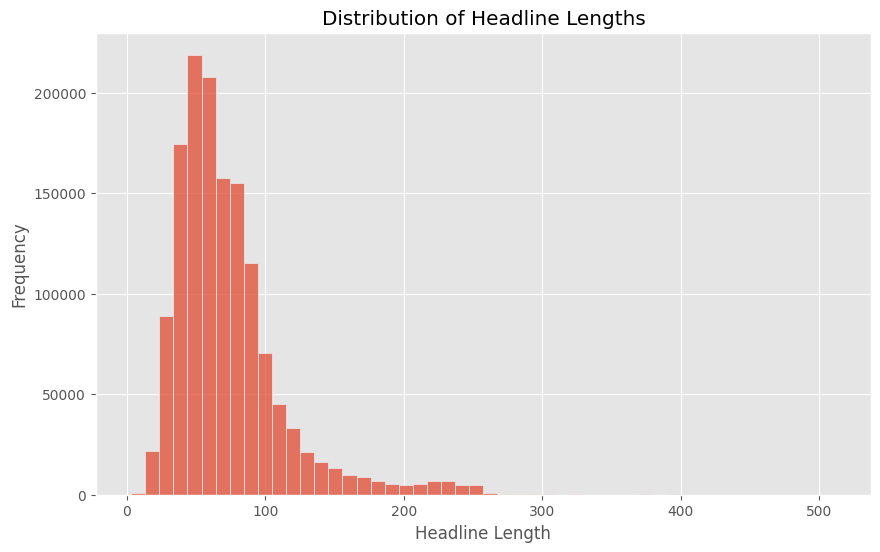

In [10]:
plt.figure(figsize=(10,6))

sns.histplot(news_df['headline_length'], bins=50)

plt.title('Distribution of Headline Lengths')
plt.xlabel('Headline Length')
plt.ylabel('Frequency')

plt.show()

### Insight

The distribution of headline lengths is right-skewed, with most headlines falling within a moderate length range. This suggests that financial news headlines are generally concise and information-dense, aiming to communicate key market events efficiently while still providing enough context for investors.

## 3. Publisher Analysis

This section identifies the most active news publishers in the dataset and examines contribution patterns across different sources.

In [11]:
top_publishers = news_df['publisher'].value_counts().head(20)

top_publishers

publisher
Paul Quintaro        228373
Lisa Levin           186979
Benzinga Newsdesk    150484
Charles Gross         96732
Monica Gerson         82380
Eddie Staley          57254
Hal Lindon            49047
ETF Professor         28489
Juan Lopez            28438
Benzinga Staff        28114
Vick Meyer            24826
webmaster             20313
Benzinga_Newsdesk     19410
Zacks                 19390
Jayson Derrick        19050
Allie Wickman         18317
Shanthi Rexaline      16640
Craig Jones           16221
Wayne Duggan          12897
Nelson Hem            12590
Name: count, dtype: int64

### Visualization

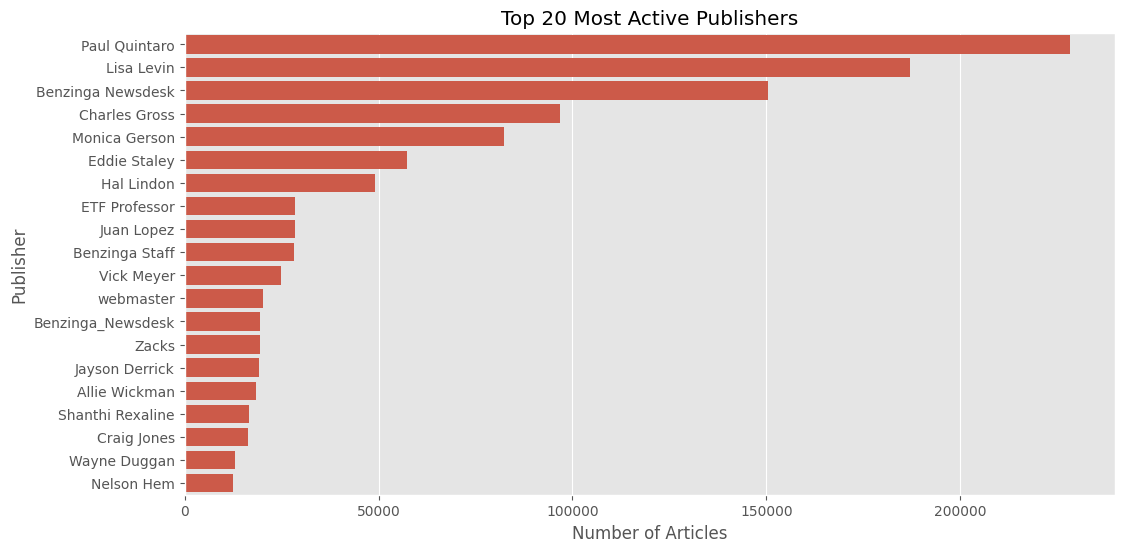

In [12]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=top_publishers.values,
    y=top_publishers.index
)

plt.title('Top 20 Most Active Publishers')
plt.xlabel('Number of Articles')
plt.ylabel('Publisher')

plt.show()

### Insight

The publisher analysis reveals that a relatively small group of publishers contributes a significant portion of the articles in the dataset. Benzinga-related sources dominate the dataset, indicating a strong concentration of financial reporting activity from a few major contributors.

## 4. Publication Trends Over Time

This section examines how news publication frequency changes over time and identifies potential spikes related to market events.

In [15]:
news_df['date'] = pd.to_datetime(
    news_df['date'],
    format='mixed',
    utc=True
)

The dataset contained mixed datetime formats within the publication date column. This issue was addressed using pandas mixed-format datetime parsing to ensure consistent timestamp handling across the dataset.

In [16]:
news_df['publication_day'] = news_df['date'].dt.date

### Daily Article Counts

In [17]:
daily_counts = news_df['publication_day'].value_counts().sort_index()

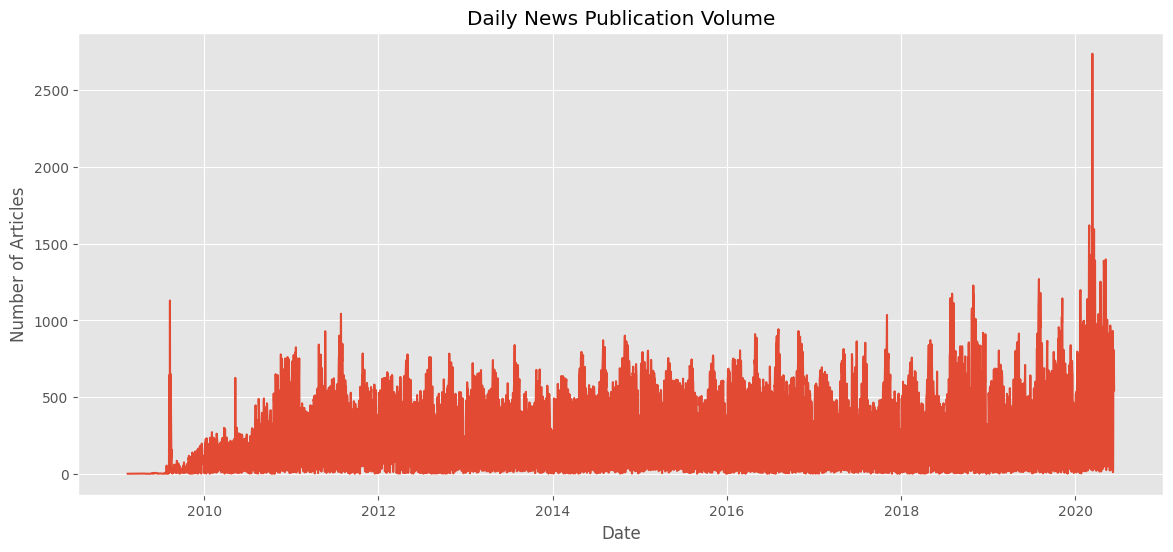

In [18]:
plt.figure(figsize=(14,6))

daily_counts.plot()

plt.title('Daily News Publication Volume')
plt.xlabel('Date')
plt.ylabel('Number of Articles')

plt.show()

### Insight

News publication activity varies significantly across time, with several noticeable spikes in article volume. These spikes may correspond to major market events, earnings seasons, economic announcements, or periods of heightened market volatility that generate increased financial reporting.

## 5. Publishing Time Analysis

This section investigates whether financial news tends to be published during specific hours of the day.

In [19]:
news_df['publication_hour'] = news_df['date'].dt.hour

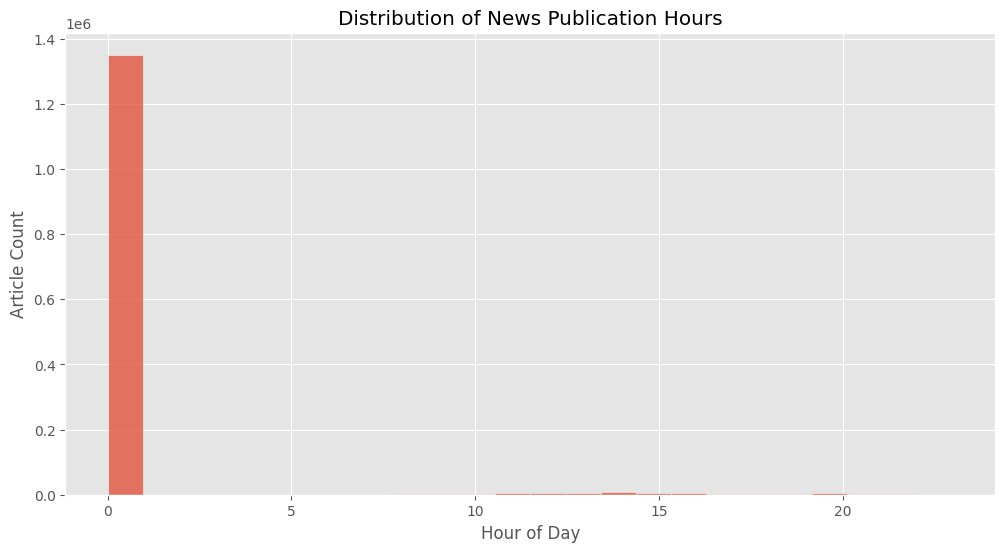

In [20]:
plt.figure(figsize=(12,6))

sns.histplot(news_df['publication_hour'], bins=24)

plt.title('Distribution of News Publication Hours')
plt.xlabel('Hour of Day')
plt.ylabel('Article Count')

plt.show()

### Insight

Most publication timestamps appear concentrated around hour 0 after datetime normalization. This suggests inconsistencies in the original timestamp formatting or timezone representation within the dataset, which may limit detailed intraday temporal analysis.

## 6. Keyword and Topic Analysis

This section identifies commonly occurring terms in financial news headlines using NLP-based vectorization techniques.

In [21]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(
    stop_words='english',
    max_features=20
)

X = vectorizer.fit_transform(news_df['headline'])

keywords = vectorizer.get_feature_names_out()
counts = X.toarray().sum(axis=0)

keyword_df = pd.DataFrame({
    'keyword': keywords,
    'count': counts
})

keyword_df = keyword_df.sort_values(by='count', ascending=False)

keyword_df

,keyword,count
18,vs,162099
15,stocks,161776
6,est,140604
5,eps,128897
7,market,120558
14,shares,114313
12,reports,108710
17,update,91723
4,earnings,87399
13,sales,79645


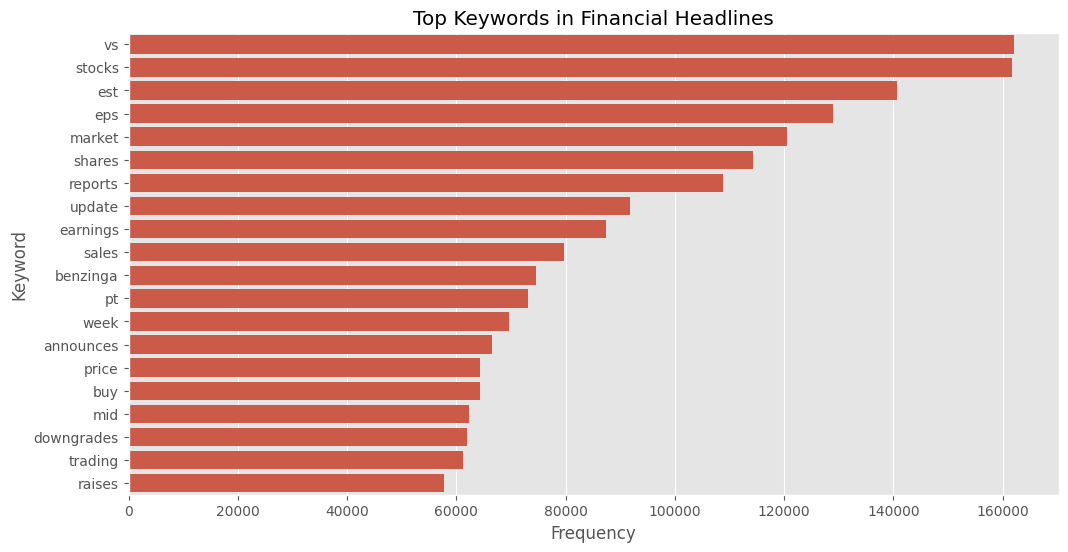

In [22]:
plt.figure(figsize=(12,6))

sns.barplot(
    x='count',
    y='keyword',
    data=keyword_df
)

plt.title('Top Keywords in Financial Headlines')
plt.xlabel('Frequency')
plt.ylabel('Keyword')

plt.show()

### Insight

The most frequent keywords strongly relate to stock performance, analyst expectations, earnings reports, and market activity. Terms such as "stocks", "market", "earnings", and "price" indicate that the dataset is heavily centered around investment analysis and market-moving financial events.

# Conclusion

The exploratory data analysis provided valuable insights into the structure and characteristics of the financial news dataset. The analysis revealed patterns in headline length, dominant publisher activity, publication frequency, and recurring financial themes.

The dataset appears highly focused on stock market activity, earnings announcements, analyst ratings, and market performance discussions. Several spikes in publication volume suggest periods of intensified financial reporting, likely linked to important market events.

These findings establish a strong foundation for the next stages of the project, including technical indicator computation, sentiment analysis, and correlation analysis between news sentiment and stock price movements.